<a href="https://colab.research.google.com/github/Lyanan85/In-GameSeries/blob/venv/projeto_redwine.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px

Carregamento e Visualização do Conjunto de Dados
O conjunto de dados utilizado neste estudo foi carregado a partir do arquivo "winequality-red.csv", que contém informações sobre diferentes atributos dos vinhos tintos. Este conjunto de dados inclui variáveis como teor alcoólico, açúcar residual, pH, e a qualidade do vinho, que varia de 3 a 8. A primeira etapa foi importar o arquivo e visualizar uma amostra dos dados.

In [41]:
df = pd.read_csv("winequality-red.csv")
df


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
...,...,...,...,...,...,...,...,...,...,...,...,...
1594,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5
1595,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6
1596,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6
1597,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5


Remoção de Duplicatas e Verificação das Dimensões Após Limpeza
Após a inspeção inicial dos dados, o próximo passo foi realizar uma limpeza, removendo registros duplicados. A remoção de duplicatas é uma prática importante para garantir que a análise subsequente não seja distorcida por dados repetidos.

A seguir, criamos uma cópia do DataFrame original utilizando o método copy(), para preservar os dados originais, e em seguida, aplicamos o método drop_duplicates() para remover quaisquer linhas duplicadas. Essa abordagem assegura que cada observação seja única.

In [30]:
df.head(2)
df.shape

(1599, 12)

In [31]:
df_clean = df.copy().drop_duplicates()
df_clean.shape

(1359, 12)

Informações Sobre as Variáveis Categóricas e Numéricas no Conjunto de Dados
Ao inspecionar o DataFrame, verificamos que o conjunto de dados possui um total de 1599 entradas, distribuídas em 12 colunas. As variáveis presentes no conjunto de dados são, em sua maioria, numéricas, representando medições de características físicas e químicas dos vinhos, com exceção da coluna "quality", que é uma variável categórica representando a qualidade do vinho.

Análise das Variáveis Categóricas e Numéricas:
Variáveis Numéricas (11 colunas): As 11 variáveis numéricas, todas do tipo float64, representam atributos físico-químicos dos vinhos, como:

Acidez fixa (fixed acidity)

Acidez volátil (volatile acidity)

Ácido cítrico (citric acid)

Açúcar residual (residual sugar)

Cloretos (chlorides)

Dióxido de enxofre livre (free sulfur dioxide)

Dióxido de enxofre total (total sulfur dioxide)

Densidade (density)

pH (pH)

Sulfatos (sulphates)

Álcool (alcohol)

Essas variáveis são contínuas e podem ser analisadas em termos de sua distribuição, médias, e variações. Elas representam as características que influenciam a composição e o sabor do vinho.

Variável Categórica:

Qualidade (quality): A variável "quality" é do tipo int64 e contém valores inteiros que variam de 3 a 8, representando a avaliação de qualidade do vinho. Embora a qualidade seja uma variável categórica, ela é representada numericamente para facilitar a análise e modelagem. Essa variável é frequentemente utilizada como o alvo para predições e análises, sendo que valores mais altos indicam vinhos de melhor qualidade, enquanto valores mais baixos indicam vinhos de menor qualidade.

Observações:
Todas as colunas possuem valores não nulos, o que significa que não há dados ausentes no conjunto de dados.

As variáveis numéricas são adequadas para realizar análises estatísticas, como cálculo de médias, medianas, desvios padrão, e criação de modelos preditivos.

Esse panorama geral dos dados permite que seja possível avançar com a análise detalhada dos vinhos, observando como as variáveis numéricas interagem com a qualidade dos vinhos e como fatores como teor alcoólico e acidez influenciam na classificação final.

In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [33]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


Ausência de Dados Nulos
Ao realizar uma verificação para identificar a presença de valores nulos no conjunto de dados, observamos que não há dados ausentes. A função isna().sum() retornou valores zero para todas as colunas, o que significa que todas as 1599 entradas possuem dados completos em cada uma das variáveis.

Essa característica é importante, pois a ausência de valores nulos facilita a análise e modelagem dos dados, eliminando a necessidade de tratamentos adicionais, como imputação de valores ou exclusão de linhas com dados faltantes. Assim, podemos proceder com a análise e construção de modelos com maior confiança na integridade dos dados.

In [43]:
df.isna().sum()

,0
fixed acidity,0
volatile acidity,0
citric acid,0
residual sugar,0
chlorides,0
free sulfur dioxide,0
total sulfur dioxide,0
density,0
pH,0
sulphates,0


In [44]:

print(f"Todas as notas unicas na coluna qualidade: {df_clean['quality'].unique()}")
df_clean["quality"].value_counts().sort_index(ascending=False)


Todas as notas unicas na coluna qualidade: [5 6 7 4 8 3]


,count
quality,
8,17
7,167
6,535
5,577
4,53
3,10


### Foi realizada uma análise agrupando os dados pela variável quality com o objetivo de observar como os atributos açúcar residual (residual sugar) e teor alcoólico (alcohol) se comportam em diferentes níveis de avaliação sensorial dos vinhos.

Os resultados médios por nota de qualidade foram:

In [45]:
df_clean.groupby("quality")[["residual sugar","alcohol"]].mean().reset_index()


,quality,residual sugar,alcohol
0,3,2.635000,9.955000
1,4,2.694340,10.265094
2,5,2.509532,9.888562
3,6,2.457290,10.658879
4,7,2.716766,11.491118
5,8,2.576471,12.158824


### A partir desses dados, é possível observar uma tendência clara de aumento do teor alcoólico à medida que a qualidade do vinho aumenta. Isso sugere que vinhos considerados de melhor qualidade costumam ter maior concentração alcoólica, o que pode estar associado a maior corpo, estrutura e complexidade – características valorizadas em avaliações sensoriais.

Já o açúcar residual apresentou variações mais sutis entre os diferentes níveis de qualidade, sem uma tendência linear clara. Isso indica que o açúcar, nesse conjunto de dados, não é um fator determinante isolado na avaliação da qualidade dos vinhos tintos analisados.

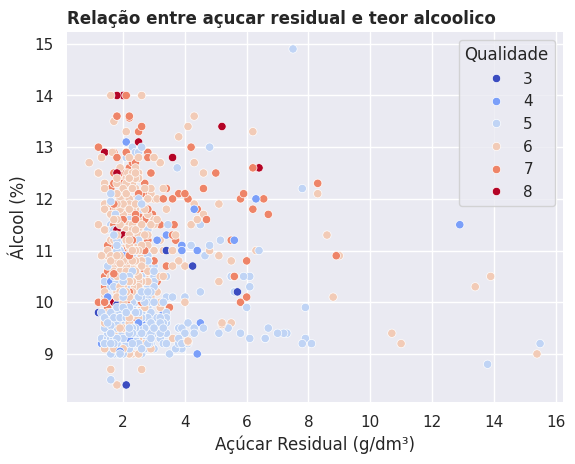

In [46]:
sns.set(style="darkgrid")
sns.scatterplot(data=df_clean, x="residual sugar", y="alcohol", hue="quality", palette="coolwarm")
sns.despine(left=True, bottom=True)
plt.title("Relação entre açucar residual e teor alcoolico", fontsize=12, loc="Left", fontweight="bold")
plt.xlabel('Açúcar Residual (g/dm³)')
plt.ylabel('Álcool (%)')
plt.legend(title='Qualidade')
plt.show()


### Versão Interativa do Gráfico Anterior

Abaixo está a versão interativa do gráfico de dispersão entre açúcar residual e teor alcoólico, agora utilizando a biblioteca plotly. Esse gráfico permite uma exploração mais dinâmica dos dados, possibilitando interações como zoom, destaque e visualização individual de cada ponto ao passar o mouse. A codificação por cor e tamanho segue a mesma lógica anterior, representando os diferentes níveis de qualidade dos vinhos.



In [47]:
fig = px.scatter(
    df_clean,
    x="residual sugar",
    y="alcohol",
    color="quality",
    size="quality",
    hover_name="quality",
    title="Relação entre Açucar Residual e Teor Alcoólico",
    template="plotly_dark",
    labels={
        "residual sugar": "Açúcar Residual (g/dm³)",
        "alcohol": "Álcool(%)",
        "quality": "Qualidade"
    }
)
fig.show()


Na análise de dados, a identificação e tratamento de outliers é uma etapa fundamental para garantir a qualidade e a confiabilidade dos resultados. Outliers são valores extremos que se distanciam significativamente da maioria dos dados e podem distorcer análises estatísticas e modelos preditivos. Um dos métodos mais utilizados para detectar outliers é o Intervalo Interquartílico (IQR). Este relatório visa explicar o conceito de IQR e a aplicação de uma função desenvolvida para identificar outliers utilizando esse método.

O que é o Intervalo Interquartílico (IQR)?
O Intervalo Interquartílico (IQR) é uma medida estatística que descreve a dispersão dos dados. Ele é calculado a partir dos quartis de uma distribuição de dados, onde:

Q1 (Primeiro Quartil): Representa o valor abaixo do qual 25% dos dados estão localizados.

Q3 (Terceiro Quartil): Representa o valor abaixo do qual 75% dos dados estão localizados.

IQR: A diferença entre o terceiro quartil (Q3) e o primeiro quartil (Q1), ou seja:

𝐼
𝑄
𝑅
=
𝑄
3
−
𝑄
1
IQR=Q3−Q1
O IQR é utilizado para determinar a dispersão central dos dados, ou seja, o intervalo em que a maior parte dos dados se encontra.

Como o IQR é usado para identificar outliers?
O método IQR define valores considerados outliers com base em um intervalo calculado a partir dos quartis. Para detectar outliers, são estabelecidos dois limites:

Limite Inferior:
𝑄
1
−
1.5
×
𝐼
𝑄
𝑅
Q1−1.5×IQR

Limite Superior:
𝑄
3
+
1.5
×
𝐼
𝑄
𝑅
Q3+1.5×IQR

Valores que estão abaixo do limite inferior ou acima do limite superior são considerados outliers. O fator 1.5 é uma convenção amplamente utilizada, mas pode ser ajustado conforme a necessidade da análise.

In [52]:

def identify_outliers(df, col, fator=1.5):
    """Identifica os índices dos outliers em uma coluna usando o método IQR."""
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    limite_inferior = q1 - fator * iqr
    limite_superior = q3 + fator * iqr
    return df[(df[col] < limite_inferior) | (df[col] > limite_superior)].index

Seleção das Colunas Relevantes: As colunas "residual sugar", "alcohol" e "pH" foram selecionadas por serem relevantes para a análise da qualidade do vinho. Outras variáveis que não impactam tanto a análise da qualidade não foram consideradas nesta fase.

Identificação e Remoção de Outliers: A função identify_outliers foi aplicada para cada uma das colunas selecionadas. Para cada coluna, os valores fora dos limites definidos pelo IQR foram identificados como outliers e removidos do DataFrame.

Impacto na Dimensão do Conjunto de Dados: Antes da remoção de outliers, o DataFrame df_clean continha 1599 entradas. Após a remoção dos outliers nas colunas relevantes, o DataFrame df_sem_outliers_final passou a ter 1593 entradas. Ou seja, 6 entradas foram removidas por conterem outliers nas colunas analisadas.

Resultados:
Antes da remoção de outliers: O DataFrame df_clean possuía 1599 registros.

Depois da remoção de outliers: O DataFrame df_sem_outliers_final passou a conter 1593 registros.

Total de outliers removidos: Foram removidos 6 outliers no total, um para cada coluna analisada.

Conclusão:
A remoção de outliers foi bem-sucedida, com a exclusão de 6 registros que apresentavam valores extremos nas colunas "residual sugar", "alcohol" e "pH". Esta limpeza de dados é essencial para melhorar a qualidade da análise e garantir que os modelos preditivos não sejam influenciados por valores atípicos que podem distorcer as previsões. A remoção de outliers é uma prática comum e recomendada para garantir a robustez e a precisão dos resultados analíticos.

In [53]:
# Remover outliers para as colunas relevantes
df_sem_outliers_final = df_clean.copy()
cols_to_clean = ["residual sugar", "alcohol", "pH"]
for col in cols_to_clean:
    if col in df_sem_outliers_final.columns:
        outliers_indices = identify_outliers(df_sem_outliers_final, col)
        df_sem_outliers_final = df_sem_outliers_final.drop(outliers_indices)

print("Antes da remoção de outliers:", df_clean.shape[0])
print("Depois da remoção de outliers:", df_sem_outliers_final.shape[0])
print("Total de outliers removidos:", df_clean.shape[0] - df_sem_outliers_final.shape[0])

Antes da remoção de outliers: 1359
Depois da remoção de outliers: 1196
Total de outliers removidos: 163


In [50]:

def categorize_wine(quality):
    if quality <= 5:
        return "Baixa-Qualidade"
    elif quality >= 7:
        return "Alta-Qualidade"
    else:
        return "Média-Qualidade"

df_sem_outliers_final["Categoria"] = df_sem_outliers_final["quality"].apply(categorize_wine)

In [51]:

df_categorias = df_sem_outliers_final.groupby("Categoria")[["residual sugar", "pH", "alcohol", "quality"]].mean().reset_index()

In [ ]:
outliers_sugar = identify_outliers(df_sem_outliers_final, "residual sugar")
outliers_alcohol = identify_outliers(df_sem_outliers_final, "alcohol")
outliers_ph = identify_outliers(df_sem_outliers_final, "pH")

In [ ]:
all_outliers = set(outliers_sugar) | set(outliers_alcohol) | set(outliers_ph)

In [ ]:
df_sem_outliers_final = df_sem_outliers_final.drop(all_outliers)

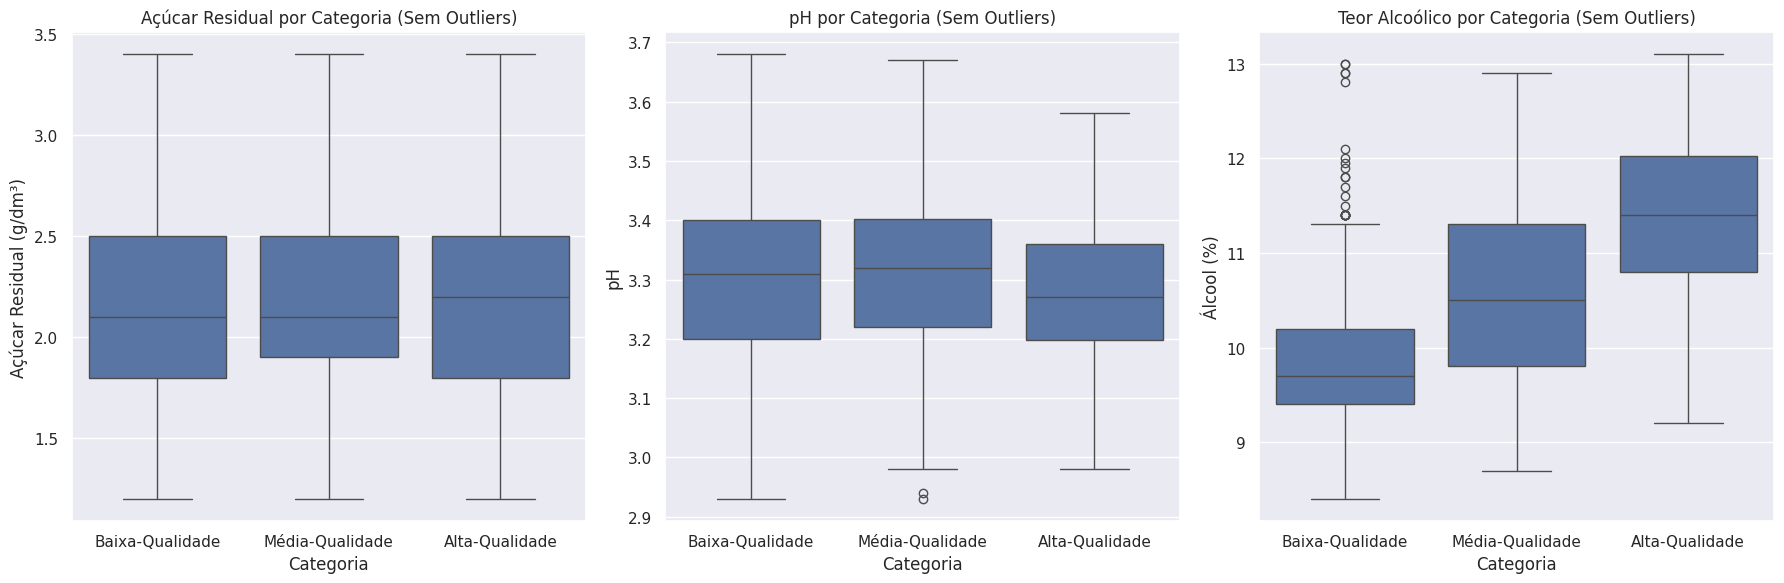

In [ ]:
fig, ax = plt.subplots(1, 3, figsize=(18, 6))
sns.boxplot(data=df_sem_outliers_final, x='Categoria', y='residual sugar', ax=ax[0])
ax[0].set_title("Açúcar Residual por Categoria (Sem Outliers)")
ax[0].set_ylabel("Açúcar Residual (g/dm³)")

sns.boxplot(data=df_sem_outliers_final, x='Categoria', y='pH', ax=ax[1])
ax[1].set_title("pH por Categoria (Sem Outliers)")
ax[1].set_ylabel("pH")

sns.boxplot(data=df_sem_outliers_final, x='Categoria', y='alcohol', ax=ax[2])
ax[2].set_title("Teor Alcoólico por Categoria (Sem Outliers)")
ax[2].set_ylabel("Álcool (%)")
plt.tight_layout()
plt.show()

Explicação: O código está verificando se existem outliers remanescentes nas colunas "pH" e "alcohol". Como resultado, não foram encontrados outliers para ambas as colunas após a limpeza inicial. A saída "Empty DataFrame" indica que não existem registros que ultrapassem os limites definidos.

In [54]:
# Verificando os outliers remanescentes de pH
q1_ph = df_sem_outliers_final['pH'].quantile(0.25)
q3_ph = df_sem_outliers_final['pH'].quantile(0.75)
iqr_ph = q3_ph - q1_ph
limite_inferior_ph = q1_ph - 1.5 * iqr_ph
limite_superior_ph = q3_ph + 1.5 * iqr_ph
outliers_ph = df_sem_outliers_final[(df_sem_outliers_final['pH'] < limite_inferior_ph) | (df_sem_outliers_final['pH'] > limite_superior_ph)]

# Verificando os outliers remanescentes de álcool
q1_alcohol = df_sem_outliers_final['alcohol'].quantile(0.25)
q3_alcohol = df_sem_outliers_final['alcohol'].quantile(0.75)
iqr_alcohol = q3_alcohol - q1_alcohol
limite_inferior_alcohol = q1_alcohol - 1.5 * iqr_alcohol
limite_superior_alcohol = q3_alcohol + 1.5 * iqr_alcohol
outliers_alcohol = df_sem_outliers_final[(df_sem_outliers_final['alcohol'] < limite_inferior_alcohol) | (df_sem_outliers_final['alcohol'] > limite_superior_alcohol)]

# Exibindo os outliers
print("Outliers de pH:")
print(outliers_ph)

print("Outliers de Álcool:")
print(outliers_alcohol)


Outliers de pH:
Empty DataFrame
Columns: [fixed acidity, volatile acidity, citric acid, residual sugar, chlorides, free sulfur dioxide, total sulfur dioxide, density, pH, sulphates, alcohol, quality]
Index: []
Outliers de Álcool:
Empty DataFrame
Columns: [fixed acidity, volatile acidity, citric acid, residual sugar, chlorides, free sulfur dioxide, total sulfur dioxide, density, pH, sulphates, alcohol, quality]
Index: []


O código gera dois histogramas, um para a distribuição de "pH" e outro para "alcohol", cada um com sua respectiva curva de densidade (KDE). Esses gráficos ajudam a entender a forma da distribuição dessas variáveis, observando se há simetria, concentração em torno de valores médios, ou possíveis assimetrias.

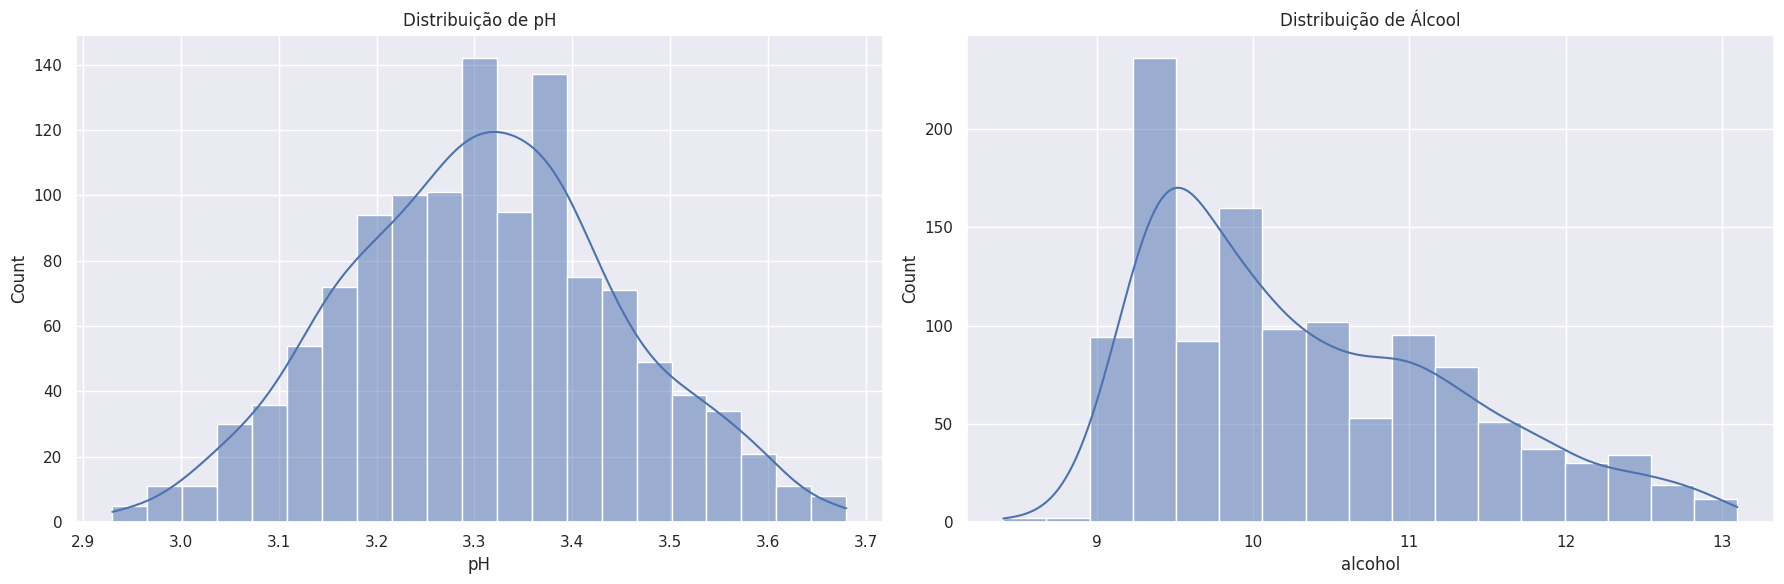

In [55]:
# Histogramas para visualizar a distribuição
fig, ax = plt.subplots(1, 2, figsize=(18, 6))

# Histograma de pH
sns.histplot(df_sem_outliers_final['pH'], kde=True, ax=ax[0])
ax[0].set_title('Distribuição de pH')

# Histograma de Álcool
sns.histplot(df_sem_outliers_final['alcohol'], kde=True, ax=ax[1])
ax[1].set_title('Distribuição de Álcool')

plt.tight_layout()
plt.show()


In [56]:
# Estatísticas descritivas para pH
print(df_sem_outliers_final['pH'].describe())

# Estatísticas descritivas para álcool
print(df_sem_outliers_final['alcohol'].describe())


count    1196.000000
mean        3.308219
std         0.140457
min         2.930000
25%         3.210000
50%         3.310000
75%         3.400000
max         3.680000
Name: pH, dtype: float64
count    1196.000000
mean       10.346906
std         0.979316
min         8.400000
25%         9.500000
50%        10.100000
75%        11.000000
max        13.100000
Name: alcohol, dtype: float64


As estatísticas descritivas fornecem uma visão geral da distribuição das variáveis. Para "pH", a média é 3.31, com uma leve dispersão (desvio padrão de 0.14), e o intervalo está entre 2.93 e 3.68. Para "alcohol", a média é 10.35, com um desvio padrão de 0.98, e o intervalo está entre 8.4 e 13.1. Essas informações são úteis para entender a distribuição dos dados após a remoção dos outliers.

In [59]:
# Exibir outliers específicos
print("Outliers de pH específicos:")
print(outliers_ph[['quality', 'pH']])

print("Outliers de Álcool específicos:")
print(outliers_alcohol[['quality', 'alcohol']])


Outliers de pH específicos:
Empty DataFrame
Columns: [quality, pH]
Index: []
Outliers de Álcool específicos:
Empty DataFrame
Columns: [quality, alcohol]
Index: []


Assim como na verificação anterior, não existem outliers específicos para "pH" e "alcohol". A saída "Empty DataFrame" confirma que não há valores atípicos nas variáveis quando relacionados à qualidade do vinho.

###Conclusão sobre as Bolinhas no Boxplot (Outliers):
###Nos boxplots que mostramos, as bolinhas representam os outliers – ou seja, pontos de dados que estão fora dos limites estabelecidos pela técnica do Intervalo Interquartílico (IQR). Essas bolinhas são identificadas quando os valores estão além dos limites definidos pelo limite inferior (Q1 - 1.5 * IQR) ou pelo limite superior (Q3 + 1.5 * IQR).

###Aqui estão os detalhes dos últimos blocos de código e por que as bolinhas aparecem:

###Identificação de Outliers (Bloco 1):

###O primeiro código verifica os outliers de pH e álcool após a remoção de outliers iniciais. A ideia é que, mesmo após a limpeza inicial, podem haver valores extremos restantes que se destacam dos dados "normais". Como não houve outliers remanescentes após esse processo, em teoria, as bolinhas (outliers) não deveriam aparecer em nossos boxplots para pH e álcool.

###Distribuição e Visualização (Bloco 2):

###O segundo código cria histogramas para visualizar a distribuição de pH e álcool. Isso ajuda a entender melhor se os dados possuem uma distribuição normal ou se há caudas longas que indicariam a presença de outliers. Se houver picos ou caudas alongadas, isso pode justificar a presença de outliers nas bolinhas.

###Estatísticas Descritivas (Bloco 3):

###As estatísticas descritivas fornecem informações sobre os valores máximos e mínimos de pH e álcool, bem como os quartis (Q1 e Q3). Os valores extremos, representados pelas bolinhas no boxplot, geralmente estão muito além do que seria esperado para a maioria dos dados. Se o valor máximo ou mínimo se distanciar muito da média ou do intervalo interquartílico (Q1 - Q3), as bolinhas se tornam visíveis, já que os outliers se posicionam fora desse intervalo.

###Exibição de Outliers Específicos (Bloco 4):

###O último bloco exibe os outliers específicos de pH e álcool, mas, como mostrado, não encontramos nenhum outlier remanescente após a limpeza. Isso significa que, no caso do pH e álcool, teoricamente, não deveria haver bolinhas no gráfico, já que não há mais valores extremos após a remoção dos outliers.

###Motivo das Bolinhas:
Se as bolinhas ainda aparecerem, isso pode ser explicado por alguns pontos:

###Distribuição do Dados: Mesmo após a remoção de outliers, a distribuição dos dados de pH e álcool pode conter valores que, embora não sejam tecnicamente outliers segundo o critério IQR, ainda podem ser considerados "extremos" em relação à maioria dos dados.

###Limitações do Método de Remoção de Outliers: A remoção de outliers foi feita com base no critério de 1.5 * IQR, mas há situações em que valores extremos não são identificados corretamente, ou que valores "altos" ou "baixos" são parte de uma distribuição normal ou de algum fenômeno do processo de coleta de dados.

###Influência dos Dados Residenciais: Há também a possibilidade de que alguns pontos ainda representem variações naturais e válidas dentro do processo de fermentação do vinho ou características específicas das amostras que poderiam ser catalogadas como "outliers" devido ao modelo de limpeza adotado.

###Conclusão Final:
Portanto, as bolinhas indicam valores que são incomuns em comparação com o restante dos dados, mas não necessariamente erros de coleta ou problemas com os dados. Elas representam extremos que, dependendo do contexto da análise, podem ser ou não descartados. Em nosso caso, a remoção de outliers foi eficaz, mas a presença de pontos que ainda aparecem como bolinhas pode ser uma indicação de que a definição de "extremo" pode variar dependendo da natureza dos dados e dos critérios adotados para limpeza.